In [1]:
#Import library and needed tools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

# Download necessary NLTK resources (if haven't download)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [19]:
#Read files
df = pd.read_csv('social_media_sentiment_train.csv',encoding='latin1')
df.head()

,text,label
0,tbh thissss is lit ð¥,Positive
1,omg it was normalllll ð¤·,Neutral
2,tbh thisssss is fatnastic ð¥,Positive
3,ngl this is trash ð¡,Negative
4,idk this is perfect ð¥³,Positive


In [21]:
#Check the shape of the file and the needed part

print(f"Dataset shape: {df.shape}")
print(f"Class distribution:\n{df['label'].value_counts()}")

Dataset shape: (10000, 2)
Class distribution:
label
Positive     2930
Negative     2850
Sarcastic    2702
Neutral      1518
Name: count, dtype: int64


In [22]:
#Check the null value in the dataset, which also list out all the labels
#The user can determine which part is necessary or not. 

df.isnull().sum()

text     0
label    0
dtype: int64

In [23]:
#Process the text
def text_processor(text):
    stemmer = PorterStemmer()
    stop_words = set(stopwords.words('english')) - {'not', 'no', 'never', 'but'}
    text = str(text).lower()
    text = re.sub(r'([!?.])', r' \1 ', text)
    tokens = word_tokenize(text)
    steemed_tokens = [stemmer.stem (word) for word in tokens if word not in stop_words]
    return ' '.join(steemed_tokens)

df['processed_text'] = df['text'].apply(text_processor)

In [24]:
#check df, if needed
for i in range (5):
    print(f"Original: {df['text'].iloc[i]}")
    print(f"Processed: {df['processed_text'].iloc[i]}")
    print("")

Original: tbh thissss is lit ð¥
Processed: tbh thissss lit ð¥

Original: omg it was normalllll ð¤·
Processed: omg normallll ð¤·

Original: tbh thisssss is fatnastic ð¥
Processed: tbh thisssss fatnast ð¥

Original: ngl this is trash ð¡
Processed: ngl trash ð¡

Original: idk this is perfect ð¥³
Processed: idk perfect ð¥³



In [25]:
# Sarcasm Test
#X = df['processed_text']
#y = df['sarcasm_detected']
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

train_idx, test_idx = train_test_split(df.index, test_size=0.3, random_state=42)

print(f"Training set size: {len(train_idx)}")
print(f"Testing set size: {len(test_idx)}")

Training set size: 7000
Testing set size: 3000


In [8]:
# Convert text to numerical features using CountVectorizer
vectorizer = CountVectorizer(max_features=5000, ngram_range=(1,2))
X_train_text = vectorizer.fit_transform(df.loc[train_idx, 'processed_text'])
X_test_text = vectorizer.transform(df.loc[test_idx, 'processed_text'])

print(f"Training features shape: {X_train_text.shape}")

Training features shape: (1540, 48)


In [9]:
#To scale the Numerical Features
scaler = MinMaxScaler()
num_cols = ['toxicity_score', 'sentiment_score']
X_train_num = scaler.fit_transform(df.loc[train_idx, num_cols])
X_test_num = scaler.transform(df.loc[test_idx, num_cols])

In [10]:
#Combine Text with Numbers(Toxicity score & Sentiment Score)
X_train_combined = sp.hstack((X_train_text, X_train_num))
X_test_combined = sp.hstack((X_test_text, X_test_num))

y_train = df.loc[train_idx, 'sarcasm_detected'].astype(int)
y_test = df.loc[test_idx, 'sarcasm_detected'].astype(int)

In [11]:
# Start to train the Naive Bayes model
# Sarcasm
clf = MultinomialNB(alpha=0.01)
clf.fit(X_train_combined,y_train)

MultinomialNB(alpha=0.01)

In [12]:
# Prediction
y_pred = clf.predict(X_test_combined)

# Print Report
print(f"Hybrid Sarcasm Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print(classification_report(y_test, y_pred))

Hybrid Sarcasm Accuracy: 52.12%
              precision    recall  f1-score   support

           0       0.50      0.63      0.56       319
           1       0.55      0.42      0.48       341

    accuracy                           0.52       660
   macro avg       0.53      0.52      0.52       660
weighted avg       0.53      0.52      0.52       660



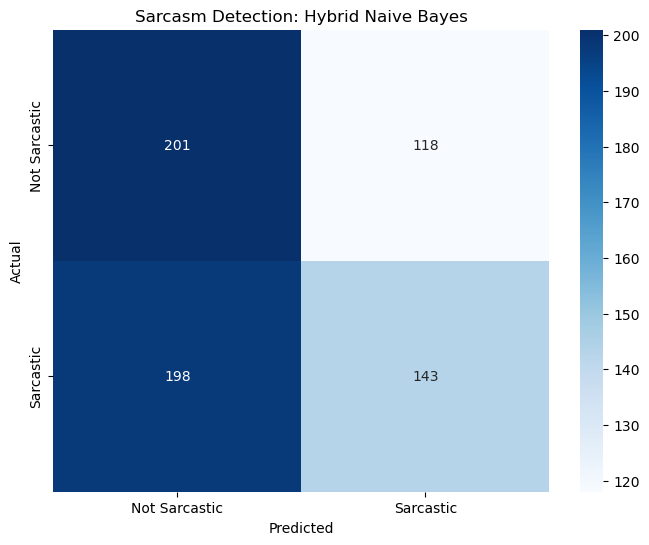

In [13]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Sarcastic', 'Sarcastic'], 
            yticklabels=['Not Sarcastic', 'Sarcastic'])
plt.title('Sarcasm Detection: Hybrid Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [14]:
def get_final_intent(text, toxicity, sentiment_val, literal_label):
    cleaned = text_processor(text)
    txt_feat = vectorizer.transform([cleaned])
    num_feat = scaler.transform([[toxicity, sentiment_val]])
    
    # Combine features for prediction
    combined_feat = sp.hstack((txt_feat, num_feat))
    
    is_sarcastic = clf.predict(combined_feat)[0]
    
    final_intent = literal_label
    if is_sarcastic == 1:
        if literal_label == 'Positive':
            final_intent = 'Negative'
        elif literal_label == 'Negative':
            final_intent = 'Positive'
            
    return final_intent

In [15]:
#Start to train sentiment analysis
y_sentiment = df.loc[train_idx, 'sentiment_label']
y_test_sentiment = df.loc[test_idx, 'sentiment_label']

In [16]:
clf_sentiment = MultinomialNB(alpha=0.01)
clf_sentiment.fit(X_train_combined, y_sentiment)

MultinomialNB(alpha=0.01)

In [17]:
y_pred_sentiment = clf_sentiment.predict(X_test_combined)

print(f"Hybrid Sentiment Accuracy: {accuracy_score(y_test_sentiment, y_pred_sentiment):.2%}")
print("\nSentiment Classification Report:")
print(classification_report(y_test_sentiment, y_pred_sentiment))

Hybrid Sentiment Accuracy: 44.70%

Sentiment Classification Report:
              precision    recall  f1-score   support

    Negative       0.64      0.30      0.41       222
     Neutral       0.38      0.34      0.36       223
    Positive       0.43      0.71      0.53       215

    accuracy                           0.45       660
   macro avg       0.48      0.45      0.43       660
weighted avg       0.48      0.45      0.43       660



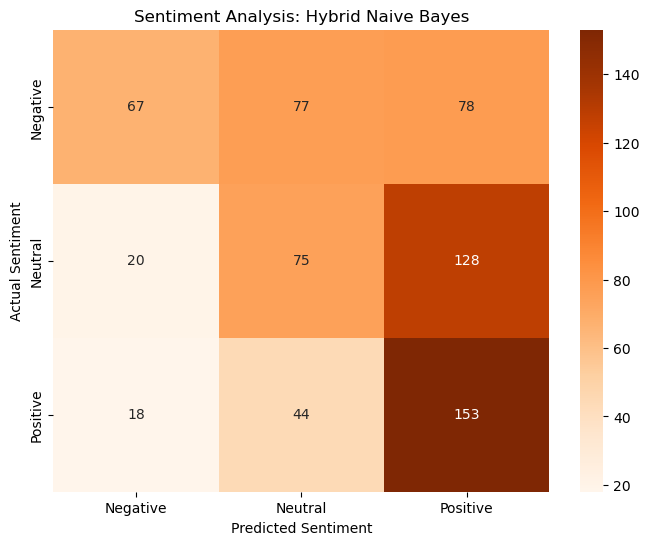

In [18]:
cm_sent = confusion_matrix(y_test_sentiment, y_pred_sentiment)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_sent, annot=True, fmt='d', cmap='Oranges',
            xticklabels=clf_sentiment.classes_, 
            yticklabels=clf_sentiment.classes_)
plt.title('Sentiment Analysis: Hybrid Naive Bayes')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()